## Summary

In this blog post, I'm going to use some data from US census and perform the following steps：

1. Train a machine learning algorithm to predict whether someone is currently employed, based on their other attributes not including race
2. Perform a bias audit of our algorithm to determine whether it displays racial bias

### Data Preparation

I'm using `folktables` to download some data.

In [2]:
from folktables import ACSDataSource, ACSEmployment, BasicProblem, adult_filter
import numpy as np

STATE = "AL"

data_source = ACSDataSource(survey_year='2018', 
                            horizon='1-Year', 
                            survey='person')

acs_data = data_source.get_data(states=[STATE], download=True)

possible_features=['AGEP', 'SCHL', 'MAR', 'RELP', 'DIS', 'ESP', 'CIT', 'MIG', 'MIL', 'ANC', 'NATIVITY', 'DEAR', 'DEYE', 'DREM', 'SEX', 'RAC1P', 'ESR']
acs_data[possible_features].head()

,AGEP,SCHL,MAR,RELP,DIS,ESP,CIT,MIG,MIL,ANC,NATIVITY,DEAR,DEYE,DREM,SEX,RAC1P,ESR
0,19,18.0,5,17,2,NaN,1,3.0,4.0,1,1,2,2,2.0,2,1,6.0
1,18,18.0,5,17,2,NaN,1,3.0,4.0,1,1,2,2,2.0,2,2,6.0
2,53,17.0,5,16,1,NaN,1,1.0,4.0,2,1,2,2,1.0,1,1,6.0
3,28,19.0,5,16,2,NaN,1,1.0,2.0,1,1,2,2,2.0,1,1,6.0
4,25,12.0,5,16,1,NaN,1,3.0,4.0,1,1,2,2,1.0,2,1,6.0


Here are some example documentations for those features:

- ESR is employment status (1 if employed, 0 if not)
- RAC1P is race (1 for White Alone, 2 for Black/African American alone, 3 and above for other self-identified racial groups)
- SEX is binary sex (1 for male, 2 for female)
- DEAR, DEYE, and DREM relate to certain disability statuses.

First, let’s subset the features we want to use:

In [5]:
features_to_use = [f for f in possible_features if f not in ["ESR", "RAC1P"]]

EmploymentProblem = BasicProblem(
    features=features_to_use,
    target='ESR',
    target_transform=lambda x: x == 1,
    group='RAC1P',
    preprocess=lambda x: x,
    postprocess=lambda x: np.nan_to_num(x, -1),
)

features, label, group = EmploymentProblem.df_to_numpy(acs_data)

for obj in [features, label, group]:
  print(obj.shape)

(47777, 15)
(47777,)
(47777,)


Before we touch the data any more, we should perform a train-test split:

In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test, group_train, group_test = train_test_split(
    features, label, group, test_size=0.2, random_state=0)

### Choose Problem

- Predict employment status on the basis of demographics excluding race, and audit for racial bias.
- I will be using random forest model from `sklearn.ensemble.RandomForestClassifier`.

### Basic Descriptives

In [26]:
import pandas as pd
df = pd.DataFrame(X_train, columns = features_to_use)
df["group"] = group_train
df["label"] = y_train

df.head()

,AGEP,SCHL,MAR,RELP,DIS,ESP,CIT,MIG,MIL,ANC,NATIVITY,DEAR,DEYE,DREM,SEX,group,label
0,46.0,20.0,2.0,0.0,2.0,0.0,1.0,1.0,4.0,1.0,1.0,2.0,2.0,2.0,2.0,1,True
1,38.0,21.0,3.0,0.0,2.0,0.0,1.0,3.0,4.0,1.0,1.0,2.0,2.0,2.0,2.0,2,True
2,22.0,19.0,5.0,2.0,2.0,0.0,1.0,1.0,4.0,1.0,1.0,2.0,2.0,2.0,2.0,2,True
3,12.0,9.0,5.0,2.0,2.0,1.0,1.0,1.0,0.0,1.0,1.0,2.0,2.0,2.0,1.0,1,False
4,40.0,22.0,1.0,0.0,2.0,0.0,1.0,1.0,4.0,1.0,1.0,2.0,2.0,2.0,1.0,1,True


1. How many individuals are in the data?

In [29]:
total = len(df)
print(f"Total individuals: {total}")

Total individuals: 38221


2. Of these individuals, what proportion have target label equal to 1? In employment prediction, these would correspond to employed individuals.

In [30]:
employed = df["label"].sum()
prop = employed / total
print(f"Proportion of employed individuals: {prop}")

Proportion of employed individuals: 0.4091468041129222


3. Of these individuals, how many are in each of the groups?

In [31]:
print("Number of individuals that are White: ", np.sum(df["group"]==1))
print("Number of individuals that are Black: ", np.sum(df["group"]==2))

Number of individuals that are White:  28441
Number of individuals that are Black:  8070


4. In each group, what proportion of individuals have target label equal to 1?

In [34]:
props = df.groupby("group")["label"].mean()
print("Proportion of individuals have target label equal to 1:")
print(props)

Proportion of individuals have target label equal to 1:
group
1    0.422629
2    0.368773
3    0.435897
4    1.000000
5    0.206897
6    0.500000
7    0.272727
8    0.369347
9    0.288084
Name: label, dtype: float64


5. Check for intersectional trends by studying the proportion of positive target labels broken out by your chosen group labels and an additional group labe. For example, if you chose race (RAC1P) as your group, then you could also choose sex (SEX) and compute the proportion of positive labels by both race and sex. 

Proportion of employed individuals by group and sex:
    group  SEX     label
0       1  1.0  0.470703
1       1  2.0  0.377164
2       2  1.0  0.356660
3       2  2.0  0.379034
4       3  1.0  0.481481
5       3  2.0  0.386667
6       4  1.0  1.000000
7       5  1.0  0.230769
8       5  2.0  0.187500
9       6  1.0  0.623711
10      6  2.0  0.406977
11      7  1.0  0.500000
12      7  2.0  0.142857
13      8  1.0  0.455446
14      8  2.0  0.280612
15      9  1.0  0.320917
16      9  2.0  0.251592


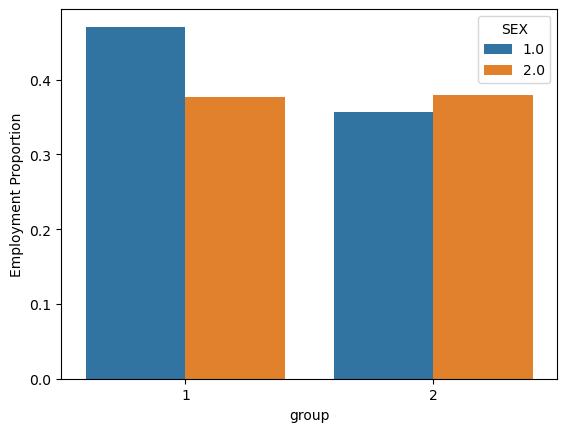

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

intersectional_prop = df.groupby(["group", "SEX"])["label"].mean().reset_index()
print("Proportion of employed individuals by group and sex:")
print(intersectional_prop)

# Visualization
sns.barplot(data=intersectional_prop, x="group", y="label", hue="SEX", order=[1, 2])
plt.ylabel("Employment Proportion")
plt.show()

Therefore, it looks like the intersectional trend looks different for those two groups. For white group, it looks more male individuals are reporting as employed, while for black group, more female individuals are reporting as employed.

### Train My Model

I want to train my random forest model on the training data. I will select `max_depth` as the tuning parameter to find the best model, along with the cross-validation method.

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix

model = make_pipeline(StandardScaler(), RandomForestClassifier())
model.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('randomforestclassifier', RandomForestClassifier())])

In [8]:
y_hat = model.predict(X_test)
(y_hat == y_test).mean()

0.7954164922561742

The default model has 0.795 accuracy.

In [11]:
from sklearn.model_selection import cross_val_score

scores = {}
max_depths = max_depths = list(range(1, 21))

for max_depth in max_depths:
    model = make_pipeline(StandardScaler(), RandomForestClassifier(max_depth=max_depth))
    model.fit(X_train, y_train)

    cv_scores = cross_val_score(model, X_train, y_train, cv=5)
    mean_score = cv_scores.mean()
    scores[max_depth] = mean_score

scores

{1: 0.6296522525093954,
 2: 0.793594877202277,
 3: 0.8131394059862714,
 4: 0.8158342753512333,
 5: 0.8163314349234184,
 6: 0.8175873047815495,
 7: 0.8189477908182944,
 8: 0.8211455759040549,
 9: 0.8222182442429103,
 10: 0.8235526241487188,
 11: 0.8243636835928717,
 12: 0.8249654080075457,
 13: 0.8254363348196853,
 14: 0.8259072753214584,
 15: 0.8247560592884333,
 16: 0.8231338822191855,
 17: 0.8213285686564206,
 18: 0.8212239456329898,
 19: 0.8185551926661896,
 20: 0.8167237695500799}

Text(0, 0.5, 'Accuracy')

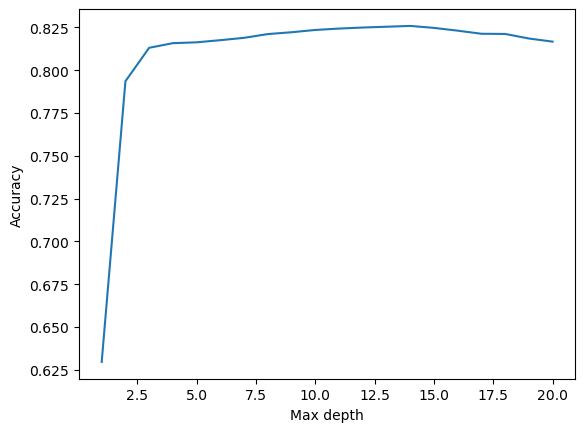

In [13]:
lists = sorted(scores.items()) # sorted by key, return a list of tuples
x, y = zip(*lists) # unpack a list of pairs into two tuples

plt.plot(x, y)
plt.xlabel('Max depth')
plt.ylabel('Accuracy')

As we can see, when `max_depth` is around 14, it achieves highest accuracy. Therefore, I will set `max_depth` to be 14 in my final model.

In [18]:
# Final model

model = make_pipeline(StandardScaler(), RandomForestClassifier(max_depth=14))
model.fit(X_train, y_train)

y_hat = model.predict(X_test)
matrix = confusion_matrix(y_test,y_hat, normalize = 'true')
TN,FN,TP,FP = matrix[0][0], matrix[1][0], matrix[1][1], matrix[0][1]

### Audit My Model

#### Overall Measures

In [19]:
print(f"1. The overall accuracy of my model is {(y_hat == y_test).mean()}")
print(f"2. The positive predictive value (PPV)  of my model is {TP/(TP+FP)}")
print(f"3. The overall false negative and false positive rates (FNR and FPR) of my model is {FN/(TP+FN)} and {FP/(FP+TN)}")

1. The overall accuracy of my model is 0.8247174550020929
2. The positive predictive value (PPV)  of my model is 0.8273970437199094
3. The overall false negative and false positive rates (FNR and FPR) of my model is 0.18186436372872747 and 0.17067093788930415


#### By-Group Measures

In [21]:
matrix1 = confusion_matrix(y_test[group_test == 1], y_hat[group_test == 1])
matrix2 = confusion_matrix(y_test[group_test == 2], y_hat[group_test == 2])

TN1,FN1,TP1,FP1 = matrix1[0][0], matrix1[1][0], matrix1[1][1], matrix1[0][1]
TN2,FN2,TP2,FP2 = matrix2[0][0], matrix2[1][0], matrix2[1][1], matrix2[0][1]

print(f"1. The overall accuracy of my model for white individual is {(y_hat == y_test)[group_test == 1].mean()}")
print(f"1. The overall accuracy of my model for black individual is {(y_hat == y_test)[group_test == 2].mean()}")

1. The overall accuracy of my model for white individual is 0.8243319268635725
1. The overall accuracy of my model for black individual is 0.8220048899755501


In [23]:
print(f"2. The positive predictive value (PPV) of my model for white individual is {TP1/(TP1+FP1)}")
print(f"2. The positive predictive value (PPV) of my model for black individual is {TP2/(TP2+FP2)}")

2. The positive predictive value (PPV) of my model for white individual is 0.7829773869346733
2. The positive predictive value (PPV) of my model for black individual is 0.7247596153846154


In [24]:
print(f"3. The overall false negative and false positive rates (FNR and FPR) of my model for white individual is {FN1/(TP1+FN1)} and {FP1/(FP1+TN1)}")
print(f"3. The overall false negative and false positive rates (FNR and FPR) of my model for black individual is {FN2/(TP2+FN2)} and {FP2/(FP2+TN2)}")

3. The overall false negative and false positive rates (FNR and FPR) of my model for white individual is 0.18289085545722714 and 0.1702389751170239
3. The overall false negative and false positive rates (FNR and FPR) of my model for black individual is 0.18292682926829268 and 0.17521040550879877


#### Bias Measures

- Is your model approximately calibrated?

The calibration measure checks whether the observed positive rate is approximately equal to the predicted positive rate. In this case, the overall accuracy can be interpreted as the predicted positive rate, and the positive predictive value (PPV) can be interpreted as the observed positive rate.

For both white and black individuals:

    White individuals: Accuracy (0.8243) vs. PPV (0.7830)
    Black individuals: Accuracy (0.8220) vs. PPV (0.7248)

Since the accuracy and PPV values are not equal for each group, the model is not calibrated in this binary score scenario.

- Does your model satisfy approximate error rate balance?

As we have already analyzed, the false negative rates (FNR) and false positive rates (FPR) for white and black individuals are quite similar:

    FNR for white individuals: 0.1829
    FNR for black individuals: 0.1829
    FPR for white individuals: 0.1702
    FPR for black individuals: 0.1752

The minimal differences in error rates between the two groups indicate that the model has approximate error rate balance.

- Does your model satisfy statistical parity?

Statistical parity is satisfied when the positive predictive value (PPV) is similar across different demographic groups. We still have the difference in PPV between white and black individuals:

    PPV for white individuals: 0.7830
    PPV for black individuals: 0.7248

The difference in PPV between the two groups is relatively larger compared to the error rates, which indicates that the model might not fully satisfy statisti*cal parity.

**In summary, based on the binary score setting, the model is not calibrated, but it has an approximate error rate balance. The model still does not fully satisfy statistical parity.**

### Concluding Discussion

1. What groups of people could stand to benefit from a system that is able to predict the label you predicted, such as income or employment status? For example, what kinds of companies might want to buy your model for commercial use?

- I think potential beneficiaries include companies in the financial sector (banks, credit bureaus, lending institutions), and they might want to use my model to predict a person's future employment status. It could be helpful for them to use the model to predict any loan risks. Furthermore, government agencies that are responsible for distributing social welfare benefits will also be interested in the model, because they can use it to distribute social goods more fairly.

2. Based on your bias audit, what could be the impact of deploying your model for large-scale prediction in commercial or governmental settings?

- Deploying the model for large-scale prediction in commercial (such as bank) may lead to unintended consequences due to the biases identified in the audit. These consequences may include unfair treatment in credit assessment or benefit distribution and biased decision-making against specific demographic groups.

3. Based on your bias audit, do you feel that your model displays problematic bias? What kind (calibration, error rate, etc)?

- Yes, the model displays problematic biases, particularly in terms of calibration and statistical parity. The calibration issue indicates that the model may not provide accurate predictions for all demographic groups, while the lack of statistical parity could result in biased decision-making against specific demographic groups.

4. Beyond bias, are there other potential problems associated with deploying your model that make you uncomfortable? How would you propose addressing some of these problems?

- Other potential problems associated with deploying the model include privacy concerns, as the model requires access to sensitive personal information to make predictions. To address these problems, I think it is essential for us to work with government agencies to perform regular audits to ensure its fairness and effectiveness, while also considering people's privacy concerns.